# GigaBERT

In [15]:
# ============================================================================
# GPU VERIFICATION 
# ============================================================================
import torch
print("="*50)
print("GPU CHECK")
print("="*50)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("WARNING: No GPU detected!")
    print("Go to Settings → Accelerator → Select 'GPU T4 x2'")
print("="*50)

GPU CHECK
CUDA available: True
Device count: 1
Current device: 0
Device name: Tesla P100-PCIE-16GB
CUDA version: 12.6


In [16]:
# FIX PROTOBUF COMPATIBILITY ISSUES
# ============================================================================
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

In [17]:
# ============================================================================
# IMPORTS
# ============================================================================
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset, load_dataset, DatasetDict
from transformers import (
    AutoConfig,
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    cohen_kappa_score, 
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [18]:

path = "/kaggle/input/refined-bayyin/Refined_Bayyin_Dataset.csv"

MODEL_NAME = "lanwuwei/GigaBERT-v4-Arabic-and-English"


OUTPUT_DIR_D3TOK = "/kaggle/working/runs/GIGABERT_D3Tok"
SAVE_DIR_D3TOK = "/kaggle/working/GigaBERT_D3Tok"


In [19]:
# Training parameters
LABEL_COL = "Readability_Level"
LEVELS = [1, 2, 3, 4, 5, 6]
LR = 3e-5
BATCH = 64
EPOCHS = 15
MAX_LEN = 128
SEED = 42

## Data Preparation

In [20]:
print("\nLoading dataset...")
dataset = load_dataset("csv", data_files={"train": path}, split="train")
print(f"Dataset columns: {dataset.column_names}")
print(f"Dataset size: {len(dataset)}")

# 70/20/10 split
train_test = dataset.train_test_split(test_size=0.3, seed=SEED)
test_valid = train_test["test"].train_test_split(test_size=1/3, seed=SEED)
splits = DatasetDict({
    "train": train_test["train"],
    "test": test_valid["train"],
    "validation": test_valid["test"],
})

print(f"Train: {len(splits['train'])}, Test: {len(splits['test'])}, Val: {len(splits['validation'])}")

# ============================================================================
# LABEL MAPPING & TOKENIZATION
# ============================================================================
level2id = {lvl: i for i, lvl in enumerate(LEVELS)}
id2level = {i: lvl for lvl, i in level2id.items()}

def map_labels(ds):
    return ds.map(lambda ex: {"labels": level2id[int(ex[LABEL_COL])]})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME,do_lower_case=True)

def tokenize_fn(batch):
    return tokenizer(batch[TEXT_COL], truncation=True, padding="max_length", max_length=MAX_LEN)


Loading dataset...
Dataset columns: ['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex', 'Readability_Level', 'Document', 'Source', 'Book', 'Author', 'Domain', 'Text_Class', 'Dataset_Source']
Dataset size: 44917
Train: 31441, Test: 8984, Val: 4492


## Model Training

In [21]:
# METRICS
# ============================================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    qwk = cohen_kappa_score(labels, preds, weights="quadratic")
    return {"accuracy": acc, "macro_f1": macro_f1, "qwk": qwk}

In [22]:
class OrdinalAwareTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        probs = torch.softmax(logits, dim=-1)

        # =========================
        # 1️⃣ HARD EXAMPLE WEIGHTING
        # =========================
        true_probs = probs.gather(1, labels.unsqueeze(1)).squeeze()

        # Hard sample → low confidence → high weight
        difficulty_weight = 1.0 - true_probs.detach()

        # Stabilize
        difficulty_weight = difficulty_weight + 0.5
        difficulty_weight = difficulty_weight / difficulty_weight.mean()

        # =========================
        # 2️⃣ ORDINAL DISTANCE PENALTY
        # =========================
        K = logits.shape[-1]
        indices = torch.arange(K).float().to(logits.device)

        labels_float = labels.float().unsqueeze(1)
        dist = torch.abs(indices - labels_float)

        distance_penalty = torch.exp(-dist / 2.0)
        distance_penalty = distance_penalty / distance_penalty.sum(dim=1, keepdim=True)

        # =========================
        # BASE LOSS (Cross Entropy)
        # =========================
        ce_loss = F.cross_entropy(logits, labels, reduction="none")

        # =========================
        # APPLY WEIGHTS
        # =========================
        weighted_loss = ce_loss * difficulty_weight

        # Optional small ordinal regularization
        log_probs = F.log_softmax(logits, dim=-1)
        ordinal_loss = F.kl_div(log_probs, distance_penalty, reduction="none").sum(dim=1)

        final_loss = (weighted_loss + 0.3 * ordinal_loss).mean()

        return (final_loss, outputs) if return_outputs else final_loss

In [23]:
# EVALUATION FUNCTION
# ============================================================================
def eval_and_report(ds, name, trainer_obj):
    out = trainer_obj.predict(ds)
    preds = out.predictions.argmax(-1)
    print(f"\n{'='*60}")
    print(f"{name} Metrics")
    print('='*60)
    print(out.metrics)
    y_true = ds["labels"]
    target_names = [f"L{lvl}" for lvl in LEVELS]
    print("\nPer-class F1:")
    print(classification_report(y_true, preds, target_names=target_names, digits=4))

def plot_confusion_matrix_normalized(ds, trainer_obj, normalize='true', cmap='Blues'):
    preds_output = trainer_obj.predict(ds)
    y_true = ds["labels"]
    y_pred = preds_output.predictions.argmax(-1)
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"L{lvl}" for lvl in LEVELS])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=cmap, values_format=".2f", ax=ax, colorbar=True)
    plt.title(f"Normalized Confusion Matrix ({normalize})")
    plt.show()

In [24]:
# ============================================================================
# TRAINING FUNCTION
# ============================================================================
def train_model(text_col, output_dir, save_dir, model_name="Model"):
    print(f"\n{'#'*60}")
    print(f"# TRAINING MODEL: {model_name}")
    print(f"# Text Column: {text_col}")
    print(f"{'#'*60}\n")

    
    # Prepare datasets
    def tokenize_fn_custom(batch):
        return tokenizer(batch[text_col], truncation=True, padding="max_length", max_length=MAX_LEN)
    
    train_ds = map_labels(splits["train"]).map(tokenize_fn_custom, batched=True)
    val_ds = map_labels(splits["validation"]).map(tokenize_fn_custom, batched=True)
    test_ds = map_labels(splits["test"]).map(tokenize_fn_custom, batched=True)
    
    cols = ["input_ids", "attention_mask", "labels"]
    train_ds.set_format(type="torch", columns=cols)
    val_ds.set_format(type="torch", columns=cols)
    test_ds.set_format(type="torch", columns=cols)

    config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=len(LEVELS),
    hidden_dropout_prob=0.2,      # Increase from default 0.1
    attention_probs_dropout_prob=0.2,  # Increase from default 0.1
)
    
    # Initialize model
    print(f"Loading model: {MODEL_NAME}")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,config=config)
    
    # Training arguments
    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=LR,
        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,
        num_train_epochs=EPOCHS,
        weight_decay=0.1,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        seed=SEED,
        report_to="none",
        save_total_limit=2,
        save_safetensors=False,
        fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    )
    
      # Initialize trainer
    trainer = OrdinalAwareTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Stops after 2 epochs of no improvement
    )

     # Train
    print(f"Starting Training for GigaBERT-v4 for {EPOCHS} epochs...")
    trainer.train()
    
    # Save model
    print(f"\nSaving fine-tuned model to: {save_dir}")
    trainer.model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print("Model and tokenizer saved successfully!")
    
    # Evaluate
    print("\nEvaluating on Test Set...")
    eval_and_report(test_ds, f"Test (AraBERTv2 + SOFT - {model_name})", trainer)
    plot_confusion_matrix_normalized(test_ds, trainer)
    
    return trainer, test_ds

In [25]:
# ============================================================================
# RESULTS SUMMARY FUNCTION
# ============================================================================
def print_summary(results):
    """Print a comparison summary of all models"""
    print("\n" + "="*80)
    print("FINAL RESULTS SUMMARY - ALL MODELS")
    print("="*80)
    print(f"{'Model':<15} {'Accuracy':<12} {'Macro F1':<12} {'QWK':<12}")
    print("-"*80)
    
    for model_name, metrics in results.items():
        acc = metrics.get('eval_accuracy', 0)
        f1 = metrics.get('eval_macro_f1', 0)
        qwk = metrics.get('eval_qwk', 0)
        print(f"{model_name:<15} {acc:<12.4f} {f1:<12.4f} {qwk:<12.4f}")
    
    print("="*80)
    
    # Find best model for each metric
    best_acc = max(results.items(), key=lambda x: x[1].get('eval_accuracy', 0))
    best_f1 = max(results.items(), key=lambda x: x[1].get('eval_macro_f1', 0))
    best_qwk = max(results.items(), key=lambda x: x[1].get('eval_qwk', 0))
    
    print(f"\nBest Accuracy: {best_acc[0]} ({best_acc[1].get('eval_accuracy', 0):.4f})")
    print(f"Best Macro F1: {best_f1[0]} ({best_f1[1].get('eval_macro_f1', 0):.4f})")
    print(f"Best QWK: {best_qwk[0]} ({best_qwk[1].get('eval_qwk', 0):.4f})")
    print("="*80)

In [26]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    results = {}
    print("STARTING TRAINING ")

STARTING TRAINING 



############################################################
# TRAINING MODEL: D3Tok
# Text Column: D3Tok
############################################################



Map:   0%|          | 0/4492 [00:00<?, ? examples/s]

Loading model: lanwuwei/GigaBERT-v4-Arabic-and-English


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at lanwuwei/GigaBERT-v4-Arabic-and-English and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 4, 'bos_token_id': 2}.


Starting Training for GigaBERT-v4 for 15 epochs...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk
1,1.454100,1.270434,0.628005,0.608276,0.771718
2,1.104900,1.043109,0.751113,0.746760,0.840556
3,0.972800,1.041276,0.759127,0.754295,0.856582
4,0.879000,1.041212,0.773375,0.769708,0.865380
5,0.800900,1.096531,0.772039,0.767918,0.866791
6,0.740400,1.113986,0.780721,0.777751,0.867537



Saving fine-tuned model to: /kaggle/working/GigaBERT_D3Tok
Model and tokenizer saved successfully!

Evaluating on Test Set...



Test (AraBERTv2 + SOFT - D3Tok) Metrics
{'test_loss': 1.044345736503601, 'test_accuracy': 0.7830587711487088, 'test_macro_f1': 0.7794180299223932, 'test_qwk': 0.8712081924239744, 'test_runtime': 31.8036, 'test_samples_per_second': 282.483, 'test_steps_per_second': 4.433}

Per-class F1:
              precision    recall  f1-score   support

          L1     0.7284    0.8334    0.7774      1519
          L2     0.7461    0.7134    0.7293      1528
          L3     0.7327    0.7960    0.7630      1353
          L4     0.6805    0.6033    0.6396      1437
          L5     0.8407    0.9484    0.8913      1530
          L6     0.9764    0.7941    0.8759      1617

    accuracy                         0.7831      8984
   macro avg     0.7841    0.7814    0.7794      8984
weighted avg     0.7882    0.7831    0.7821      8984



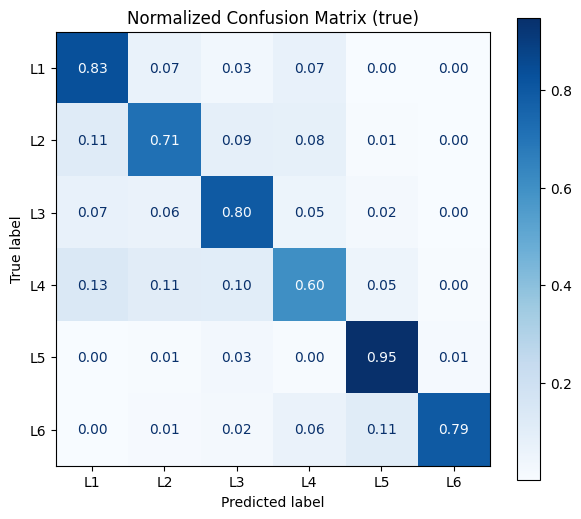

In [27]:
    # Train D3Tok
    trainer_d3tok, test_ds_d3tok = train_model("D3Tok", OUTPUT_DIR_D3TOK, SAVE_DIR_D3TOK, "D3Tok")
    results["D3Tok"] = trainer_d3tok.evaluate(test_ds_d3tok)

In [28]:
    print_summary(results)
    print("\n" + "="*80)
    print("ALL TRAINING COMPLETE!")
    print("="*80)
    print(f"\nModels saved to:\n {SAVE_DIR_D3TOK}\n  ")
    print("="*80)


FINAL RESULTS SUMMARY - ALL MODELS
Model           Accuracy     Macro F1     QWK         
--------------------------------------------------------------------------------
D3Tok           0.7831       0.7794       0.8712      

Best Accuracy: D3Tok (0.7831)
Best Macro F1: D3Tok (0.7794)
Best QWK: D3Tok (0.8712)

ALL TRAINING COMPLETE!

Models saved to:
 /kaggle/working/GigaBERT_D3Tok
  
